# Import libs

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')
nltk.download('stopwords')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
!unzip /root/nltk_data/corpora/wordnet.zip -d /root/nltk_data/corpora/

Archive:  /root/nltk_data/corpora/wordnet.zip
   creating: /root/nltk_data/corpora/wordnet/
  inflating: /root/nltk_data/corpora/wordnet/lexnames  
  inflating: /root/nltk_data/corpora/wordnet/data.verb  
  inflating: /root/nltk_data/corpora/wordnet/index.adv  
  inflating: /root/nltk_data/corpora/wordnet/adv.exc  
  inflating: /root/nltk_data/corpora/wordnet/index.verb  
  inflating: /root/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /root/nltk_data/corpora/wordnet/data.adj  
  inflating: /root/nltk_data/corpora/wordnet/index.adj  
  inflating: /root/nltk_data/corpora/wordnet/LICENSE  
  inflating: /root/nltk_data/corpora/wordnet/citation.bib  
  inflating: /root/nltk_data/corpora/wordnet/noun.exc  
  inflating: /root/nltk_data/corpora/wordnet/verb.exc  
  inflating: /root/nltk_data/corpora/wordnet/README  
  inflating: /root/nltk_data/corpora/wordnet/index.sense  
  inflating: /root/nltk_data/corpora/wordnet/data.noun  
  inflating: /root/nltk_data/corpora/wordnet/data.adv  


# EDA

In [ ]:
# Load the dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Convert to a DataFrame for easier manipulation
df = pd.DataFrame({'text': newsgroups.data, 'target': newsgroups.target})

# Map target labels to their corresponding category names
df['category'] = df['target'].apply(lambda x: newsgroups.target_names[x])

# Display the first few rows
print(df.head())

                                                text  target  \
0  \n\nI am sure some bashers of Pens fans are pr...      10   
1  My brother is in the market for a high-perform...       3   
2  \n\n\n\n\tFinally you said what you dream abou...      17   
3  \nThink!\n\nIt's the SCSI card doing the DMA t...       3   
4  1)    I have an old Jasmine drive which I cann...       4   

                   category  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  


In [ ]:
print(df.columns)

Index(['text', 'target', 'category'], dtype='object')


In [ ]:
print("Number of classes: ", len(df.category.value_counts()))
print("Number of documents of each class\n", df.category.value_counts())

Number of classes:  20
Number of documents of each class
 category
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


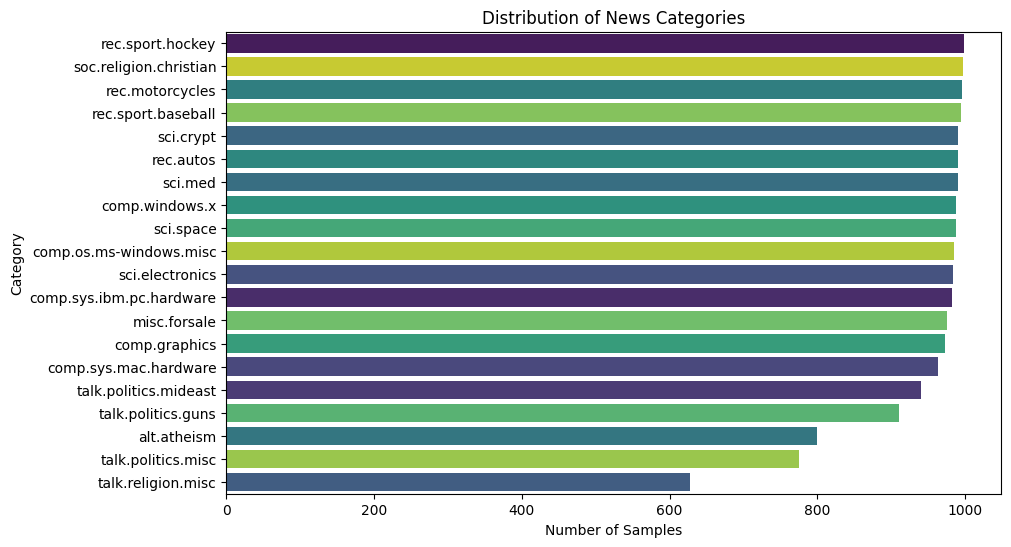

In [ ]:
# Plot the distribution of categories
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, hue='category', palette='viridis')
plt.title('Distribution of News Categories')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


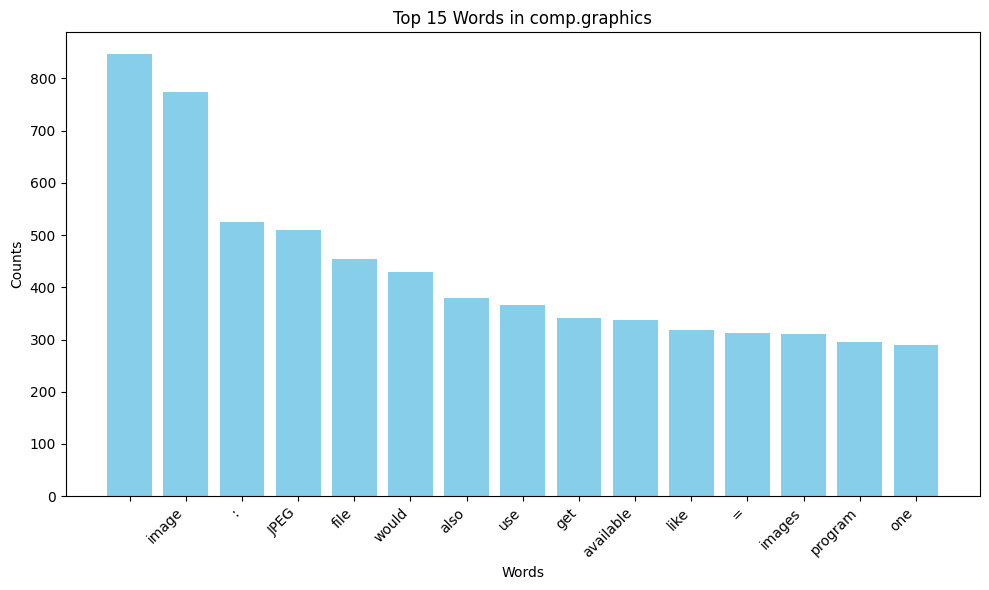

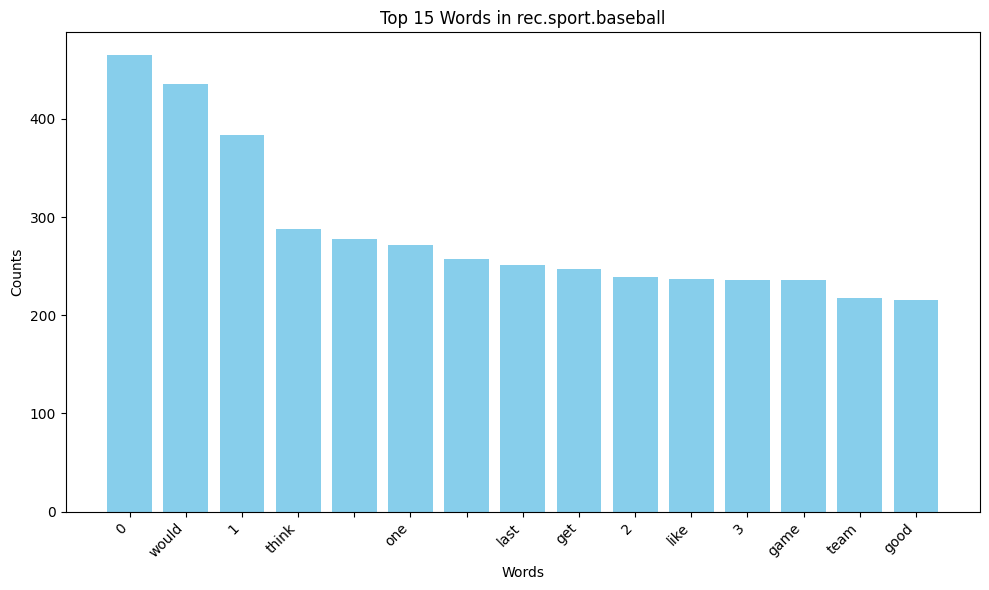

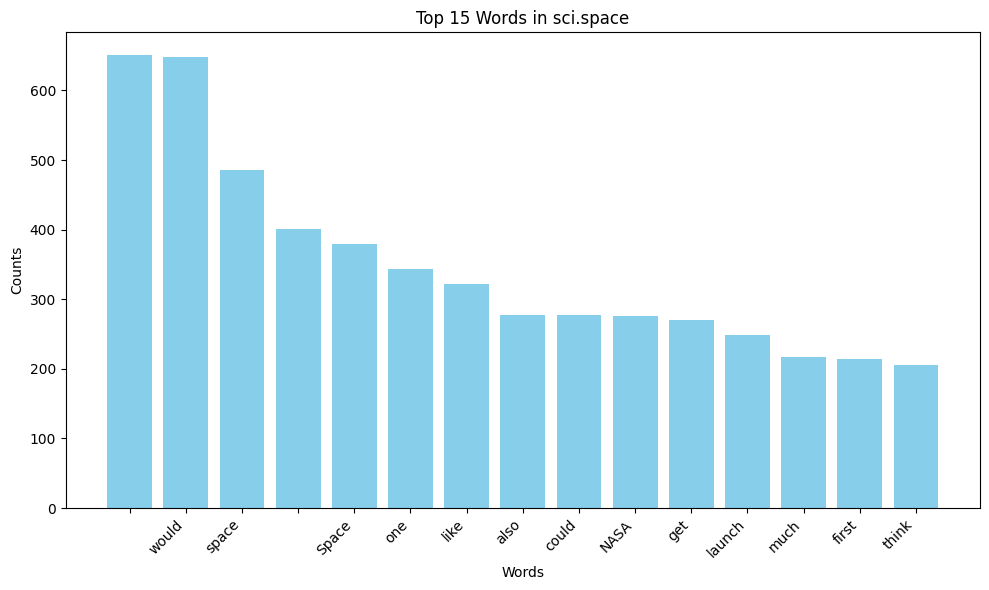

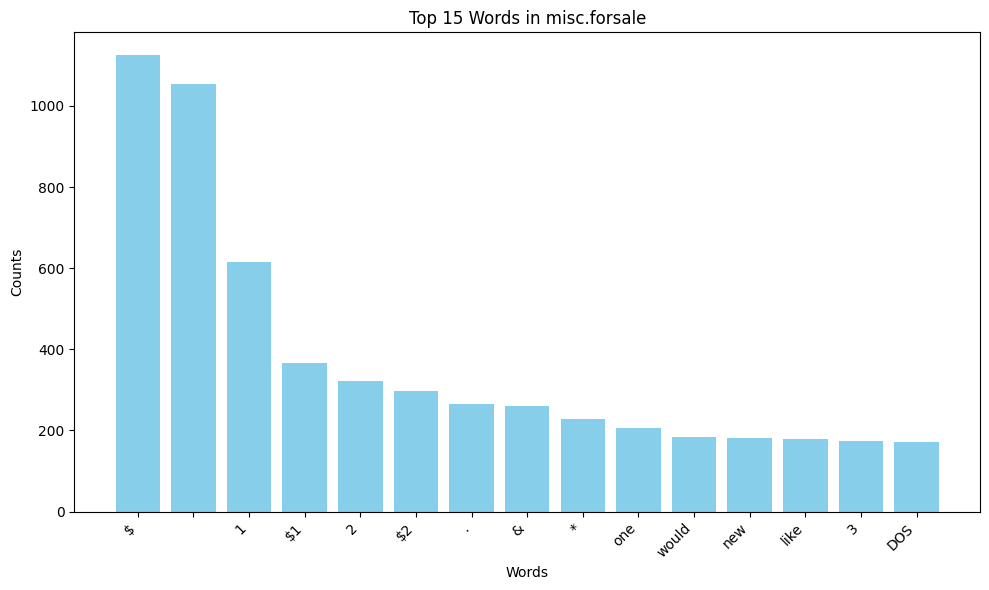

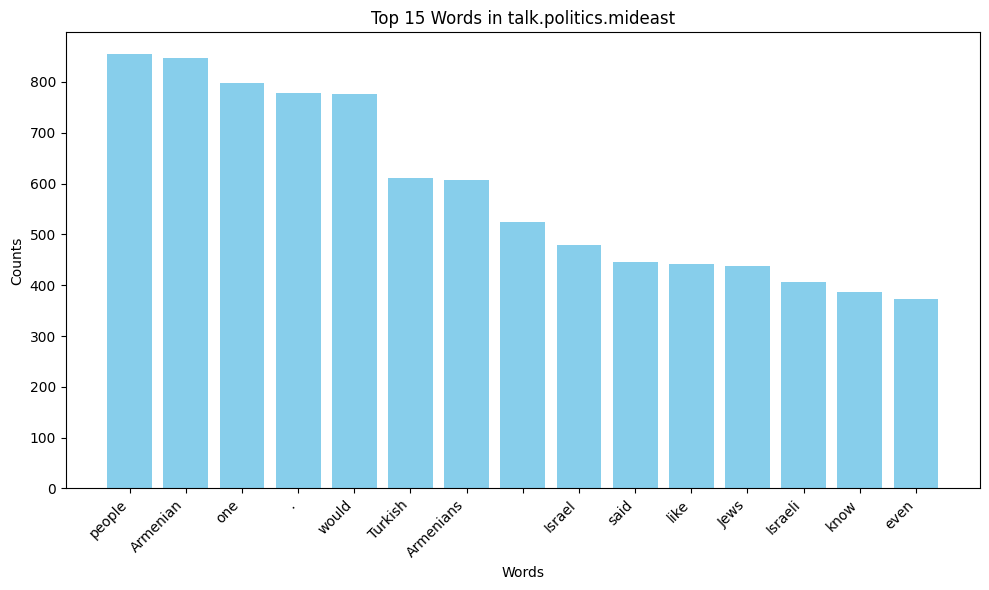

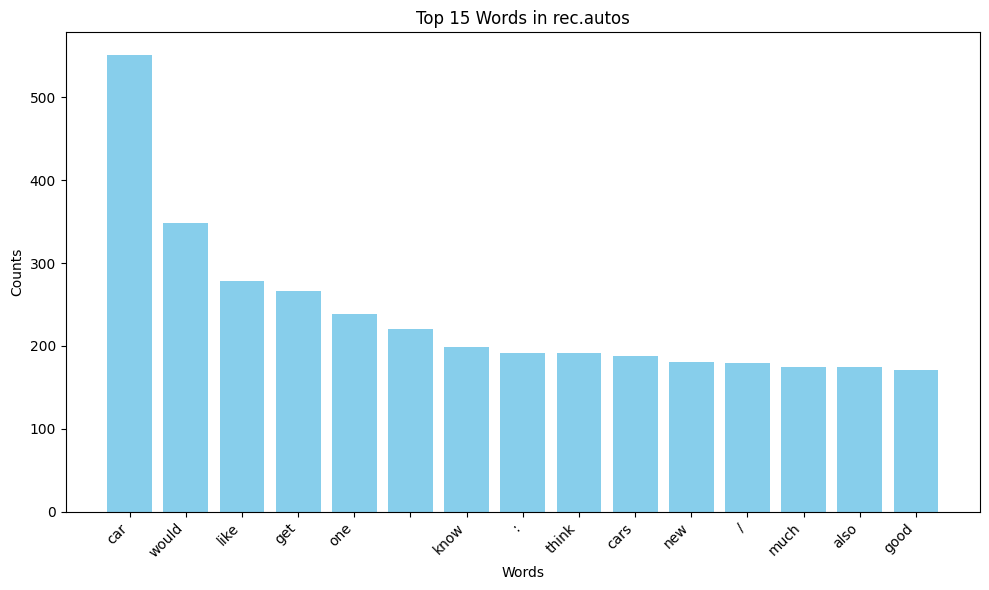

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re # Import thư viện re
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def plot_top_words_for_category(df, category, n=20):
        category_df = df[df['category'] == category]
        # Lọc bỏ stop words trước khi đếm
        all_words = ' '.join(category_df['text']).split()
        # Loại bỏ dấu gạch ngang
        filtered_words = [re.sub(r'-', ' ', word) for word in all_words]
        # Loại bỏ stop words
        filtered_words = [word for word in filtered_words if word.lower() not in stop_words]
        word_counts = Counter(filtered_words)
        top_words = word_counts.most_common(n)

        words, counts = zip(*top_words)

        plt.figure(figsize=(10, 6))
        plt.bar(words, counts, color='skyblue')
        plt.title(f'Top {n} Words in {category}')
        plt.xlabel('Words')
        plt.ylabel('Counts')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

categories = ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'misc.forsale', 'talk.politics.mideast', 'rec.autos']
for category in categories:
        plot_top_words_for_category(df, category, 15)

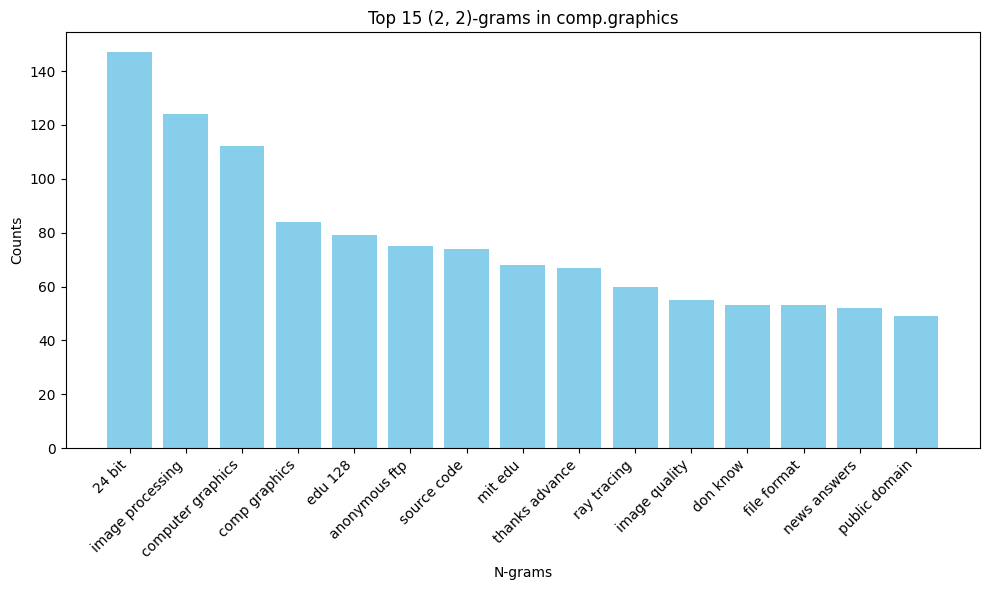

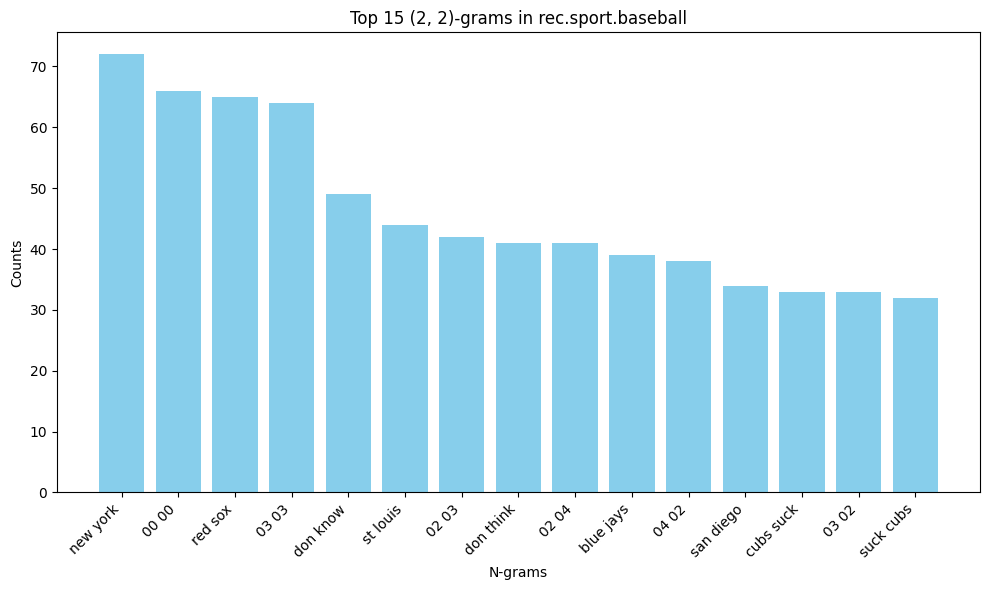

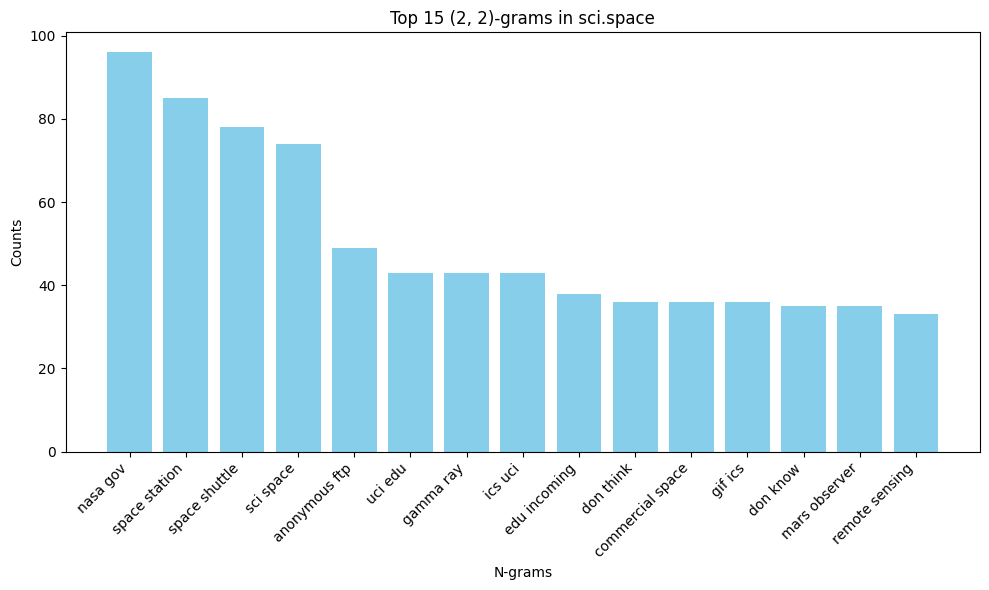

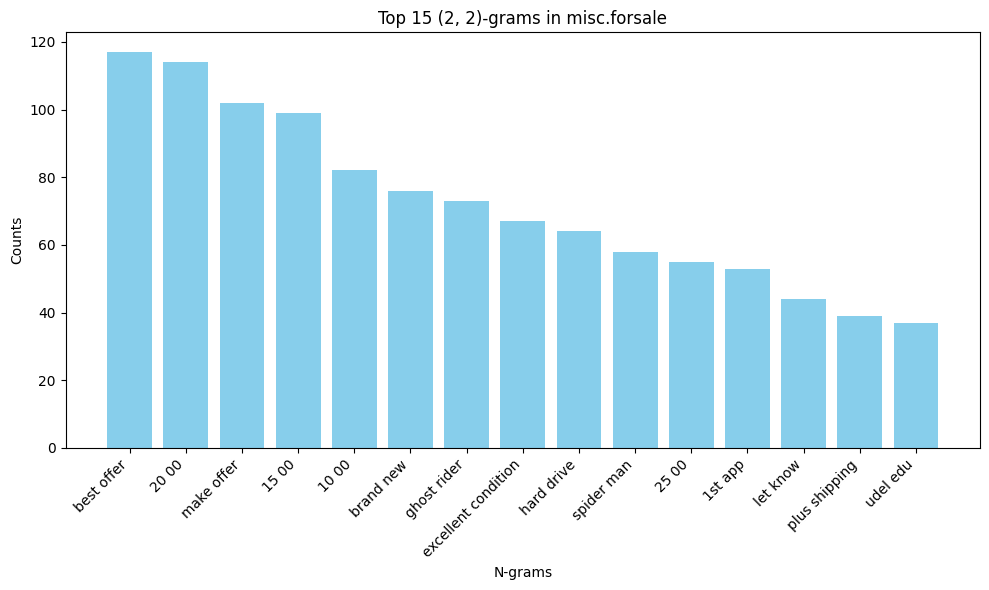

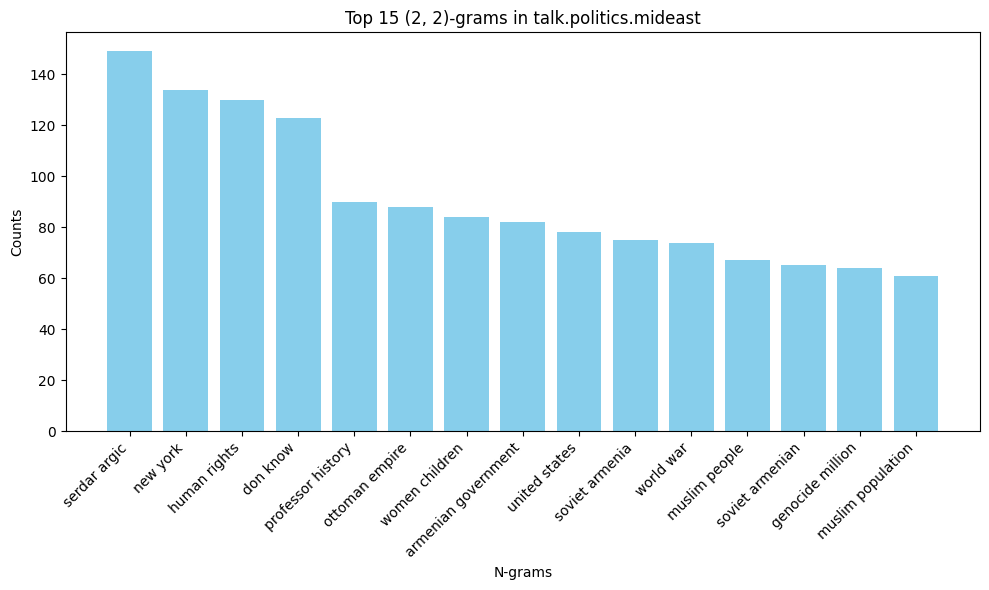

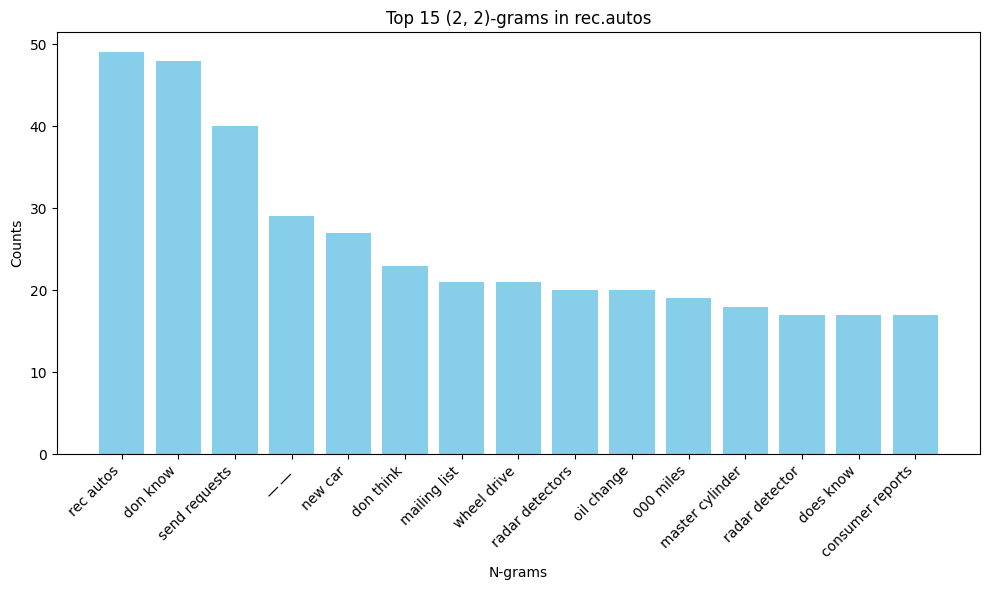

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams_for_category(df, category, n=15, ngram_range=(2, 2)):
        category_df = df[df['category'] == category]

        vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
        vectorizer.fit(category_df['text'])

        ngram_counts = vectorizer.transform(category_df['text']).sum(axis=0)
        feature_names = vectorizer.get_feature_names_out()

        ngram_counts = ngram_counts.tolist()[0]
        ngram_df = pd.DataFrame({'ngram': feature_names, 'count': ngram_counts})
        ngram_df = ngram_df.sort_values('count', ascending=False).head(n)

        plt.figure(figsize=(10, 6))
        plt.bar(ngram_df['ngram'], ngram_df['count'], color='skyblue')
        plt.title(f'Top {n} {ngram_range}-grams in {category}')
        plt.xlabel('N-grams')
        plt.ylabel('Counts')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

for category in categories:
        plot_top_ngrams_for_category(df, category, ngram_range=(2,2)) # bigrams

In [ ]:
'''from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tsne_for_categories(df, n_components=2, perplexity=30, n_iter=300):
        vectorizer = TfidfVectorizer(max_features=5000)  # Keep top 5000 features
        X = vectorizer.fit_transform(df['text']).toarray()

        tsne = TSNE(n_components=n_components, perplexity=perplexity, n_iter=n_iter, random_state=42)
        X_tsne = tsne.fit_transform(X)

        tsne_df = pd.DataFrame(X_tsne, columns=[f'component_{i}' for i in range(1, n_components + 1)])
        tsne_df['category'] = df['category'].values

        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=tsne_df, x='component_1', y='component_2', hue='category', palette='viridis')
        plt.title('TSNE Visualization of Categories')
        plt.xlabel('TSNE Component 1')
        plt.ylabel('TSNE Component 2')
        plt.legend(title='Categories')
        plt.show()

plot_tsne_for_categories(df)'''

"from sklearn.manifold import TSNE\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\ndef plot_tsne_for_categories(df, n_components=2, perplexity=30, n_iter=300):\n        vectorizer = TfidfVectorizer(max_features=5000)  # Keep top 5000 features\n        X = vectorizer.fit_transform(df['text']).toarray()\n\n        tsne = TSNE(n_components=n_components, perplexity=perplexity, n_iter=n_iter, random_state=42)\n        X_tsne = tsne.fit_transform(X)\n\n        tsne_df = pd.DataFrame(X_tsne, columns=[f'component_{i}' for i in range(1, n_components + 1)])\n        tsne_df['category'] = df['category'].values\n\n        plt.figure(figsize=(12, 8))\n        sns.scatterplot(data=tsne_df, x='component_1', y='component_2', hue='category', palette='viridis')\n        plt.title('TSNE Visualization of Categories')\n        plt.xlabel('TSNE Component 1')\n        plt.ylabel('TSNE Component 2')\n        plt.legend(title='Categories')

# Data preparation

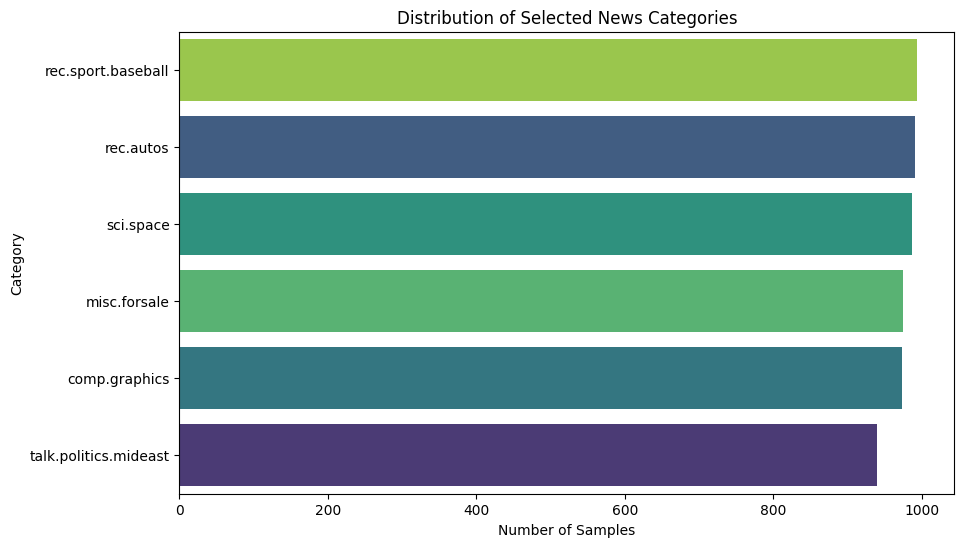

In [ ]:
# Filter the dataframe to include only the specified categories
categories = ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'misc.forsale', 'talk.politics.mideast', 'rec.autos']
filtered_df = df[df['category'].isin(categories)].copy()

# Plot the distribution of the selected categories
plt.figure(figsize=(10, 6))
sns.countplot(data=filtered_df, y='category', order=filtered_df['category'].value_counts().index, hue='category', palette='viridis', legend=False)
plt.title('Distribution of Selected News Categories')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.show()


In [ ]:
# Fetch the 20 Newsgroups dataset
data_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42
)

data_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42
)

# Extract text data and labels
X_train_text = data_train.data  # Training text data
X_test_text = data_test.data    # Test text data
y_train = data_train.target     # Training labels
y_test = data_test.target       # Test labels

# Convert labels to consecutive integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Print unique labels to verify
print("Remapped labels in y_train:", np.unique(y_train))
num_classes = len(label_encoder.classes_)  # Ensure model output layer matches this

Remapped labels in y_train: [0 1 2 3 4 5]


In [ ]:
# Tính độ dài token trước tiền xử lý
df['original_length'] = df['text'].apply(lambda x: len(x.split()))
print(df['original_length'].describe())

count    18846.000000
mean       181.637748
std        501.333800
min          0.000000
25%         40.000000
50%         83.000000
75%        166.000000
max      11765.000000
Name: original_length, dtype: float64


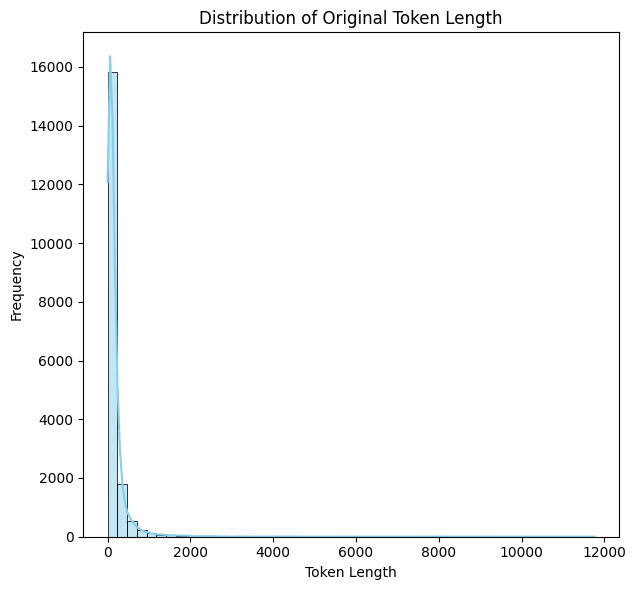

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Biểu đồ độ dài token trước tiền xử lý
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['original_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Original Token Length')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
# Initialize stemmer and lemmatizer
porter = PorterStemmer() # Stemming: 'running' -> 'run'
wnl = WordNetLemmatizer() # Lemmatization: 'better' -> 'good'

class DataPreprocess:

    def __init__(self):
        self.filters = [
            self.strip_tags,
            self.strip_numeric,
            self.strip_punctuation,
            lambda x: x.lower(),
            self.remove_stopwords,
            self.lemmatize_text
        ]

    def __call__(self, doc):
        clean_words = self.__apply_filter(doc)
        return clean_words

    def __apply_filter(self, doc):
        try:
            for filter_func in self.filters:
                doc = filter_func(doc)
            return doc
        except TypeError as te:
            raise TypeError("Not a valid data {}".format(te))

    def strip_tags(self, text):
        # Remove HTML/XML tags
        return re.sub(r'<[^>]+>', '', text)

    def strip_numeric(self, text):
        # Remove numeric characters
        return re.sub(r'\d+', '', text)

    def strip_punctuation(self, text):
        # Remove punctuation
        return re.sub(r'[^\w\s]', '', text)

    def remove_stopwords(self, text):
        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        return ' '.join([word for word in text.split() if word not in stop_words])

    def lemmatize_text(self, text):
        # Lemmatize text
        return ' '.join([wnl.lemmatize(word) for word in text.split()])

# Example usage
preprocessor = DataPreprocess()
doc = "<p>This is a sample document with 123 numbers and some stopwords like 'the' and 'is'.</p>"
cleaned_doc = preprocessor(doc)
print(cleaned_doc)

sample document number stopwords like


In [ ]:
# Initialize stemmer and lemmatizer
porter = PorterStemmer()  # Stemming: 'running' -> 'run'
wnl = WordNetLemmatizer()  # Lemmatization: 'better' -> 'good'

# Define a sample document
doc = "<p>This is a sample document with 123 numbers and some stopwords like 'the' and 'is'.</p>"

# Step 1: Strip HTML/XML tags
def strip_tags(text):
    return re.sub(r'<[^>]+>', '', text)

cleaned_doc = strip_tags(doc)
print("After stripping tags:", cleaned_doc)

# Step 2: Strip numeric characters
def strip_numeric(text):
    return re.sub(r'\d+', '', text)

cleaned_doc = strip_numeric(cleaned_doc)
print("After stripping numeric characters:", cleaned_doc)

# Step 3: Strip punctuation
def strip_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

cleaned_doc = strip_punctuation(cleaned_doc)
print("After stripping punctuation:", cleaned_doc)

# Step 4: Convert to lowercase
def to_lowercase(text):
    return text.lower()

cleaned_doc = to_lowercase(cleaned_doc)
print("After converting to lowercase:", cleaned_doc)

# Step 5: Remove stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    return ' '.join([word for word in text.split() if word not in stop_words])

cleaned_doc = remove_stopwords(cleaned_doc)
print("After removing stopwords:", cleaned_doc)

# Step 6: Lemmatize text
def lemmatize_text(text):
    return ' '.join([wnl.lemmatize(word) for word in text.split()])

cleaned_doc = lemmatize_text(cleaned_doc)
print("After lemmatization:", cleaned_doc)

After stripping tags: This is a sample document with 123 numbers and some stopwords like 'the' and 'is'.
After stripping numeric characters: This is a sample document with  numbers and some stopwords like 'the' and 'is'.
After stripping punctuation: This is a sample document with  numbers and some stopwords like the and is
After converting to lowercase: this is a sample document with  numbers and some stopwords like the and is
After removing stopwords: sample document numbers stopwords like
After lemmatization: sample document number stopwords like


In [ ]:
def preprocess_text(text):
    """Apply all preprocessing steps to a single text."""
    text = strip_tags(text)
    text = strip_numeric(text)
    text = strip_punctuation(text)
    text = to_lowercase(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [ ]:
# Apply preprocessing to the training and test sets
X_train_cleaned = [preprocess_text(text) for text in X_train_text]
X_test_cleaned = [preprocess_text(text) for text in X_test_text]

In [ ]:
X_train_text[0:1]

['Organization: University of Notre Dame - Office of Univ. Computing\nFrom: <RVESTERM@vma.cc.nd.edu>\nSubject: Re: Bosox win again! (the team record is 9-3)\n <1993Apr18.233404.16702@ncar.ucar.edu>\nLines: 12\n\nIn article <1993Apr18.233404.16702@ncar.ucar.edu>, amj@rsf.atd.ucar.edu (Anthony\nMichael Jivoin) says:\n>\n>With the "HAWK", the Red Sox definitely have a chance for the\n>east this year. He brings class, work ethic and leadership to\n>the park each day.\n>\n\ntoo bad he doesn\'t bring the ability to hit, pitch, field or run.\n\nbob vesterman.\n\n']

In [ ]:
X_train_cleaned[0:1]

['organization university notre dame office univ computing subject bosox win team record line article amjrsfatducaredu anthony michael jivoin say hawk red sox definitely chance east year brings class work ethic leadership park day bad doesnt bring ability hit pitch field run bob vesterman']

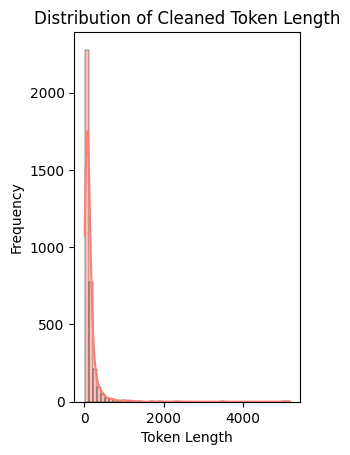

In [ ]:
df_cleaned = pd.DataFrame({'text': X_train_cleaned})
df_cleaned['cleaned_length'] = df_cleaned['text'].apply(lambda x: len(x.split()))

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['cleaned_length'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Cleaned Token Length')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()

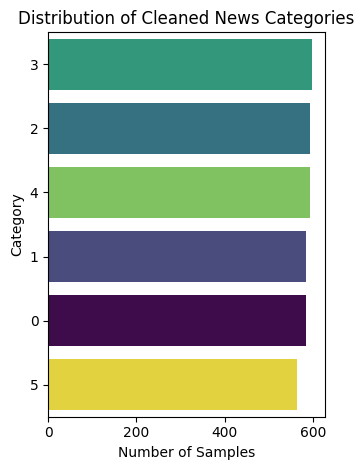

In [ ]:
df_cleaned_with_category = pd.DataFrame({'text': X_train_cleaned, 'category': pd.Series(label_encoder.inverse_transform(y_train))})
# Plotting the distribution of categories after cleaning
plt.subplot(1, 2, 2)
sns.countplot(data=df_cleaned_with_category, y='category', order=df_cleaned_with_category['category'].value_counts().index, hue='category', palette='viridis', legend=False)
plt.title('Distribution of Cleaned News Categories')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

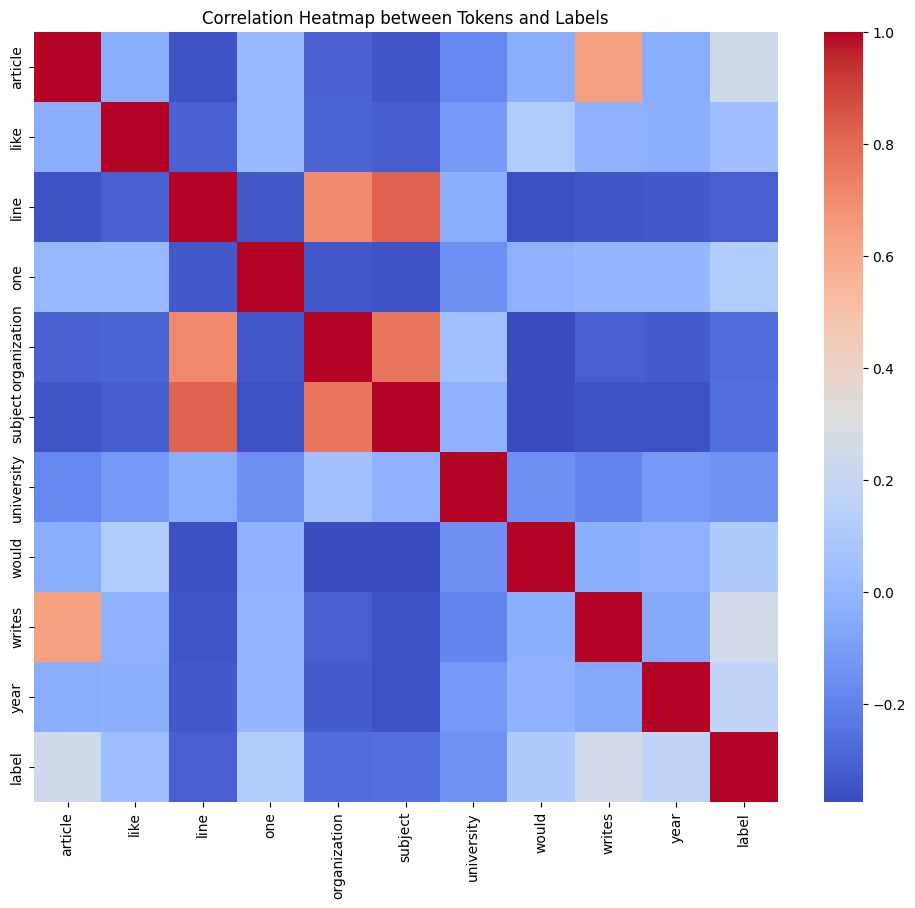

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo vectorizer TF-IDF
vectorizer = TfidfVectorizer(max_features=10)  # Chọn số lượng token đặc trưng
X = vectorizer.fit_transform(df_cleaned['text']).toarray()
tokens = vectorizer.get_feature_names_out()

df_corr = pd.DataFrame(X, columns = tokens)
df_corr['label'] = y_train # Use y_train instead
# Tính ma trận tương quan
correlation_matrix = df_corr.corr(method='pearson')

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap between Tokens and Labels')
plt.show()

# CNN

CNN and expect sequential data (word-by-word or token-by-token). When you use TF-IDF, you get a bag-of-words representation (or n-grams) in a high-dimensional vector, which does not preserve the natural word-order sequence.

In [ ]:
# Hyperparameters
embedding_dim = 64
max_len = 200         # Maximum sequence length
dropout_rate = 0.6
filters = 64
learning_rate = 0.0003

## Experiment with kernel_size and vocab_size


Training with vocab=100, kernel=3
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2119 - loss: 1.7854 - val_accuracy: 0.3366 - val_loss: 1.7557
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3775 - loss: 1.7326 - val_accuracy: 0.3594 - val_loss: 1.6661
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4048 - loss: 1.6300 - val_accuracy: 0.3807 - val_loss: 1.5888
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4063 - loss: 1.5495 - val_accuracy: 0.3736 - val_loss: 1.5459
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4119 - loss: 1.5250 - val_accuracy: 0.3793 - val_loss: 1.5250
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4075 - loss: 1.5134 - val_accuracy: 0.3793 - val_loss: 1.5093
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4202 - loss: 1.4723 - val_accuracy: 0.3977 - val_loss: 1.4933
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4519 - loss: 1.4537 - val_accuracy: 0.4062 - val_loss: 1.

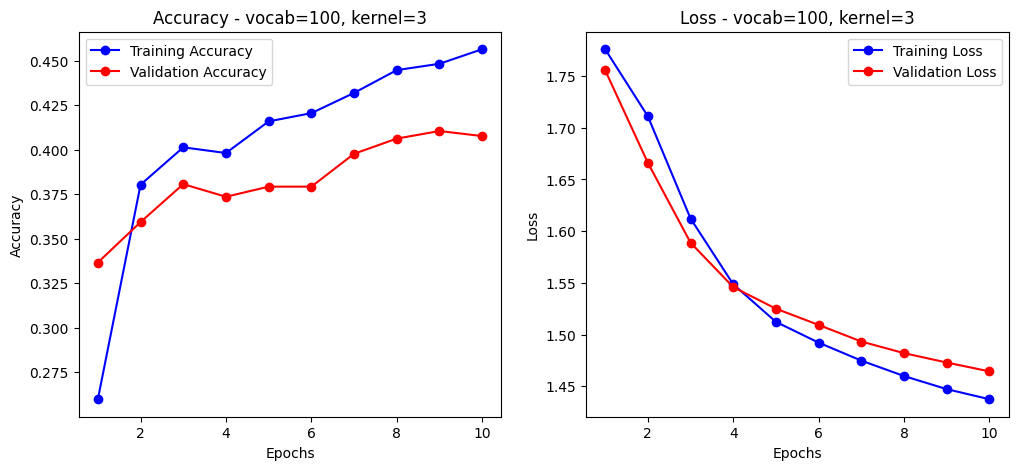


Training with vocab=100, kernel=5
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2281 - loss: 1.7858 - val_accuracy: 0.2983 - val_loss: 1.7485
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3415 - loss: 1.7243 - val_accuracy: 0.3409 - val_loss: 1.6529
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3823 - loss: 1.6008 - val_accuracy: 0.3764 - val_loss: 1.5846
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3758 - loss: 1.5654 - val_accuracy: 0.3906 - val_loss: 1.5502
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3999 - loss: 1.5263 - val_accuracy: 0.3991 - val_loss: 1.5311
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4083 - loss: 1.5005 - val_accuracy: 0.4119 - val_loss: 1.5184
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4373 - loss: 1.4807 - val_accuracy: 0.3963 - val_loss: 1.4991
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4153 - loss

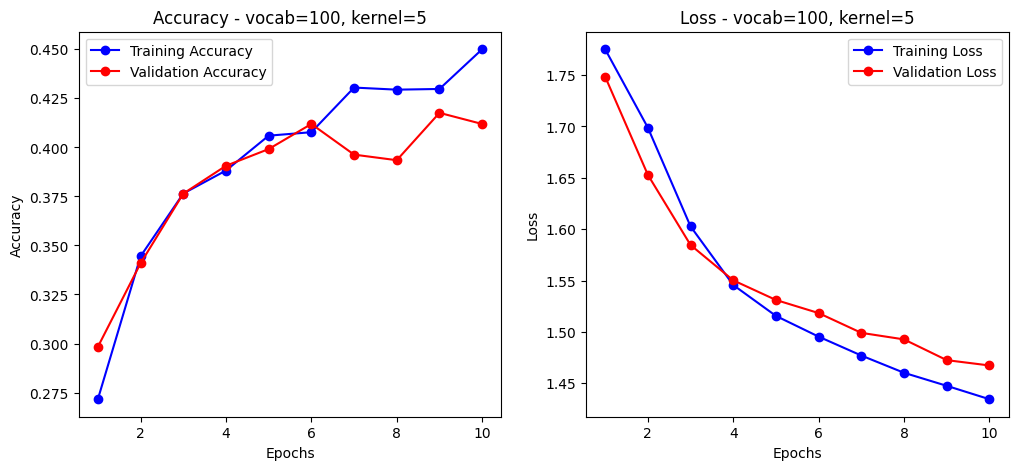


Training with vocab=15000, kernel=3
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2013 - loss: 1.7862 - val_accuracy: 0.4233 - val_loss: 1.7429
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6947 - loss: 1.6844 - val_accuracy: 0.7330 - val_loss: 1.5799
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8481 - loss: 1.4442 - val_accuracy: 0.7557 - val_loss: 1.2574
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8186 - loss: 1.0788 - val_accuracy: 0.7642 - val_loss: 0.9724
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8362 - loss: 0.7802 - val_accuracy: 0.7955 - val_loss: 0.7817
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8739 - loss: 0.5648 - val_accuracy: 0.8338 - val_loss: 0.6426
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9042 - loss: 0.4484 - val_accuracy: 0.8679 - val_loss: 0.5440
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9349 - lo

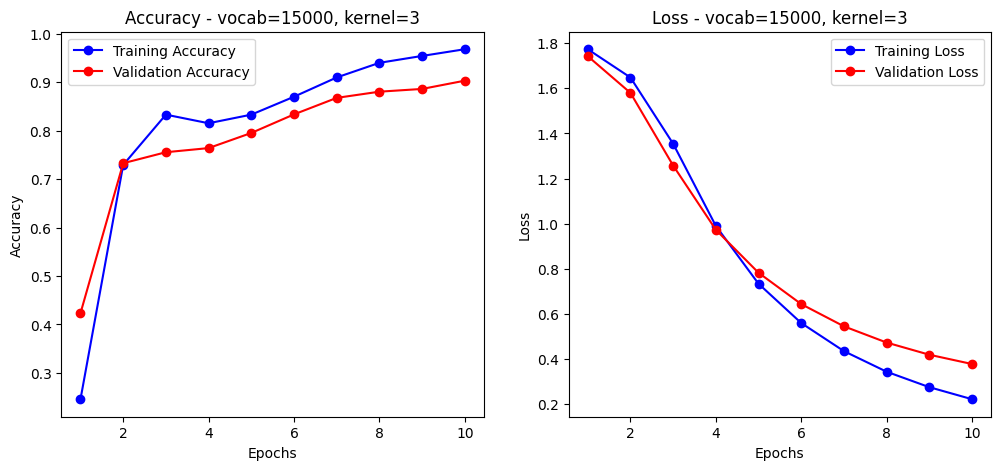


Training with vocab=15000, kernel=5
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1949 - loss: 1.7860 - val_accuracy: 0.4418 - val_loss: 1.7556
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7020 - loss: 1.7131 - val_accuracy: 0.7401 - val_loss: 1.6614
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9347 - loss: 1.5367 - val_accuracy: 0.8253 - val_loss: 1.3429
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9168 - loss: 1.1450 - val_accuracy: 0.8139 - val_loss: 1.0207
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8958 - loss: 0.8211 - val_accuracy: 0.8210 - val_loss: 0.8035
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9182 - loss: 0.6019 - val_accuracy: 0.8494 - val_loss: 0.6553
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9425 - loss: 0.4415 - val_accuracy: 0.8750 - val_loss: 0.5521
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9557 - lo

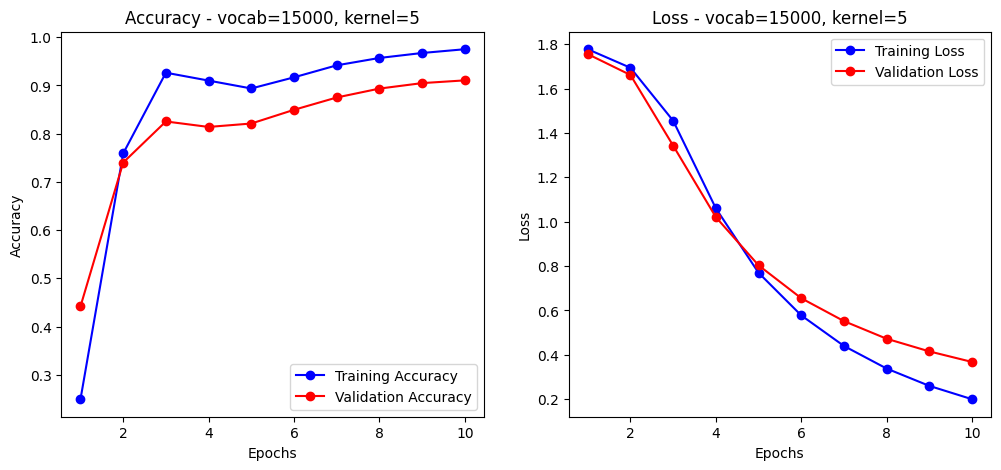


Training with vocab=30000, kernel=3
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2119 - loss: 1.7833 - val_accuracy: 0.5966 - val_loss: 1.7387
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8857 - loss: 1.6858 - val_accuracy: 0.8182 - val_loss: 1.5899
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9152 - loss: 1.4443 - val_accuracy: 0.7912 - val_loss: 1.2370
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8655 - loss: 1.0243 - val_accuracy: 0.7827 - val_loss: 0.9228
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8454 - loss: 0.7309 - val_accuracy: 0.7940 - val_loss: 0.7392
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8791 - loss: 0.5519 - val_accuracy: 0.8239 - val_loss: 0.6160
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9096 - loss: 0.4258 - val_accuracy: 0.8466 - val_loss: 0.5295
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9493 - lo

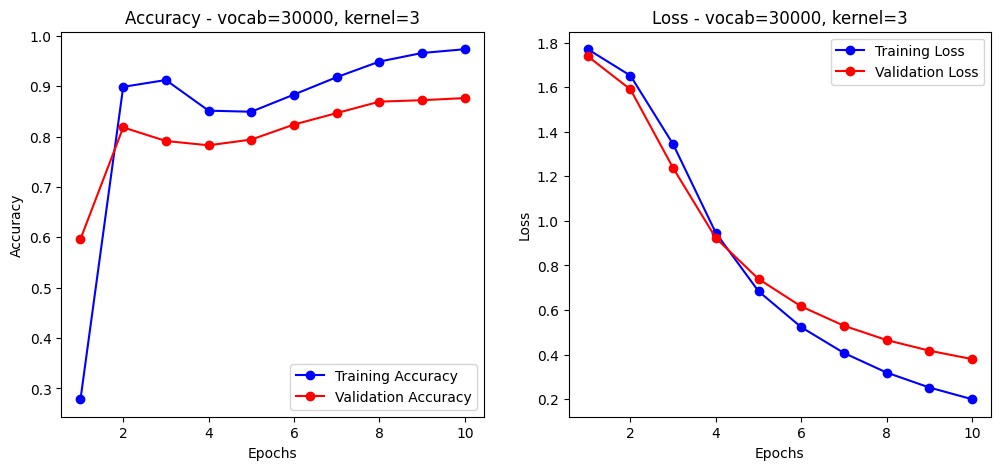


Training with vocab=30000, kernel=5
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2186 - loss: 1.7829 - val_accuracy: 0.4105 - val_loss: 1.7498
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8199 - loss: 1.7003 - val_accuracy: 0.7429 - val_loss: 1.6335
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9456 - loss: 1.4943 - val_accuracy: 0.8381 - val_loss: 1.3178
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9307 - loss: 1.1074 - val_accuracy: 0.8097 - val_loss: 1.0297
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9123 - loss: 0.8152 - val_accuracy: 0.8111 - val_loss: 0.8500
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9176 - loss: 0.6329 - val_accuracy: 0.8338 - val_loss: 0.7080
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9363 - loss: 0.4932 - val_accuracy: 0.8509 - val_loss: 0.5934
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9592 - lo

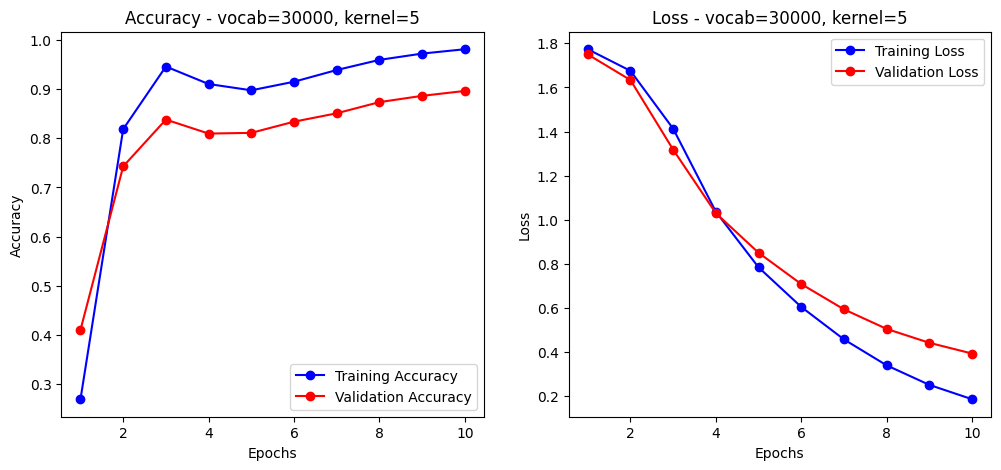


Summary of Configurations:
vocab=100, kernel=3: Test Accuracy = 0.4317
vocab=100, kernel=5: Test Accuracy = 0.4342
vocab=15000, kernel=3: Test Accuracy = 0.8783
vocab=15000, kernel=5: Test Accuracy = 0.8886
vocab=30000, kernel=3: Test Accuracy = 0.8740
vocab=30000, kernel=5: Test Accuracy = 0.8907


In [ ]:
num_classes = len(np.unique(y_train))  # number of classes

# Parameter grids to experiment with:
vocab_sizes = [100, 15000, 30000]
kernel_sizes = [3, 5]

# To store results for later comparison
results = []

# Loop over combinations of vocabulary size and kernel size.
for vocab_size in vocab_sizes:
    for kernel_size in kernel_sizes:
        config = f"vocab={vocab_size}, kernel={kernel_size}"
        print(f"\nTraining with {config}")

        # --- Tokenization and Padding ---
        tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>") #“out-of-vocabulary token”.
        # By default, if you don’t use oov_token, unknown words are simply discarded (skipped).
        # Using oov_token helps the model handle unseen words instead of ignoring them completely.
        tokenizer.fit_on_texts(X_train_text)
        X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
        X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)

        # By default, padding and truncating is "pre"
        X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)#, padding='post', truncating='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)#, padding='post', truncating='post')

        # Simplified Model
        model_cnn = Sequential([
            Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
            Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
            GlobalMaxPooling1D(),
            Dense(num_classes, activation='softmax')
        ])

        # --- Create a New Optimizer Instance for This Model ---
        optimizer_choice = 'adam'

        # --- Compile the Model ---
        model_cnn.compile(
            loss='sparse_categorical_crossentropy',
            optimizer=Adam(learning_rate=learning_rate),
            metrics=['accuracy']
        )
        if optimizer_choice == 'adam':
            optimizer = Adam(learning_rate=learning_rate)
        elif optimizer_choice == 'sgd':
            optimizer = SGD(learning_rate=learning_rate)
        elif optimizer_choice == 'rmsprop':
            optimizer = RMSprop(learning_rate=learning_rate)
        else:
            raise ValueError("Invalid optimizer choice.")

        # --- Train the Model ---
        history_cnn = model_cnn.fit(
            X_train_pad, y_train,
            epochs=10,
            batch_size=32,
            validation_split=0.2,
            verbose=1
        )

        # --- Evaluate the Model ---
        test_loss, test_accuracy = model_cnn.evaluate(X_test_pad, y_test, verbose=0)
        print(f"Test Accuracy with {config}: {test_accuracy:.4f}")

        # Save the configuration and results
        results.append({
            'config': config,
            'vocab_size': vocab_size,
            'kernel_size': kernel_size,
            'test_accuracy': test_accuracy,
            'history': history_cnn.history
        })

        # --- Visualization ---
        epochs = range(1, len(history_cnn.history['accuracy']) + 1)
        plt.figure(figsize=(12, 5))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history_cnn.history['accuracy'], 'bo-', label='Training Accuracy')
        plt.plot(epochs, history_cnn.history['val_accuracy'], 'ro-', label='Validation Accuracy')
        plt.title(f'Accuracy - {config}')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history_cnn.history['loss'], 'bo-', label='Training Loss')
        plt.plot(epochs, history_cnn.history['val_loss'], 'ro-', label='Validation Loss')
        plt.title(f'Loss - {config}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        plt.show()


# --- Summary of All Configurations ---
print("\nSummary of Configurations:")
for res in results:
    print(f"{res['config']}: Test Accuracy = {res['test_accuracy']:.4f}")


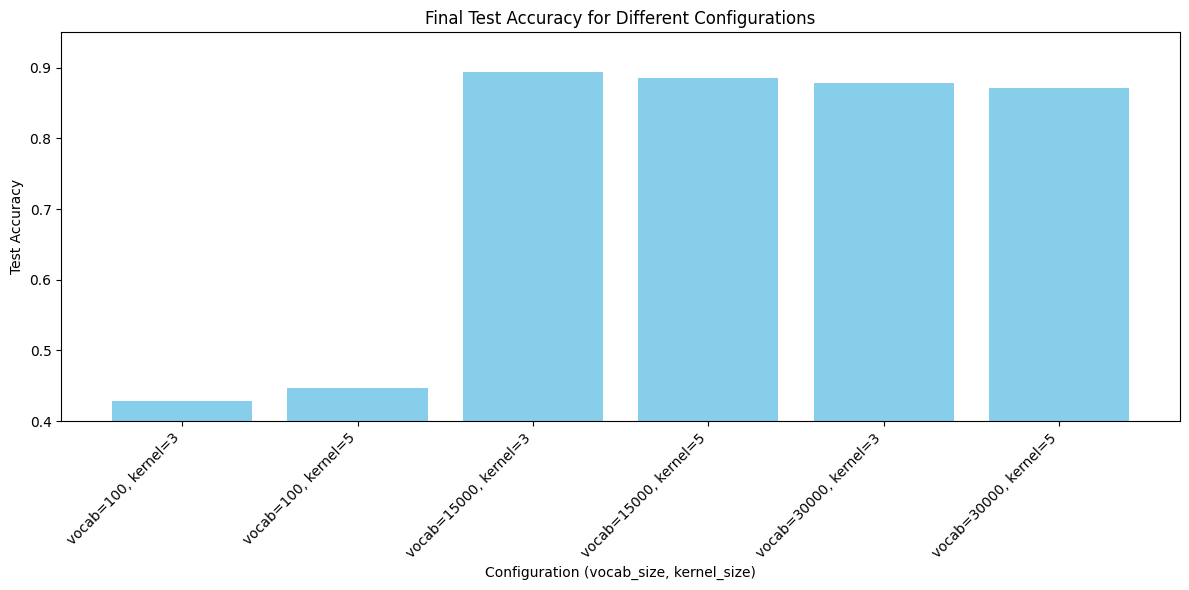

In [ ]:
import matplotlib.pyplot as plt

# Data from the summary table
vocab_sizes = ['100', '100', '15000', '15000', '30000', '30000']
kernel_sizes = ['3', '5', '3', '5', '3', '5']
test_accuracies = [0.4278, 0.4462, 0.8937, 0.8851, 0.8783, 0.8706]

labels = [f'vocab={v}, kernel={k}' for v, k in zip(vocab_sizes, kernel_sizes)]

plt.figure(figsize=(12, 6))
plt.bar(labels, test_accuracies, color='skyblue')
plt.ylim(0.40, 0.95)
plt.title('Final Test Accuracy for Different Configurations')
plt.ylabel('Test Accuracy')
plt.xlabel('Configuration (vocab_size, kernel_size)')

# Rotate x-tick labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout so labels and titles fit within the figure
plt.tight_layout()

plt.show()

Based on this, vocab_size = 15000 and kernel =3 perform the best. We choose this for the fine-tune CNN

## Fine-tune CNN

In [ ]:
# Hyperparameters for the fine-tuned model
embedding_dim = 64
max_len = 200
dropout_rate = 0.6
filters = 64
learning_rate = 0.0003
vocab_size = 15000  # Best vocab size from experiments
kernel_size = 3     # Best kernel size from experiments
activation_funcs = ['relu', 'sigmoid', 'tanh'] # List of activation functions to test

# Tokenization and Padding (using best parameters from previous steps)
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# To store results for later comparison
results = []

for activation_func in activation_funcs:
    print(f"\nTraining with activation function: {activation_func}")

    # Define the fine-tuned CNN model
    model_cnn_tuned = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        Conv1D(filters=filters, kernel_size=kernel_size, activation=activation_func),
        GlobalMaxPooling1D(),
        Dense(num_classes, activation='softmax') # Keep softmax for the output layer
    ])


    # Optimizer
    optimizer = Adam(learning_rate=learning_rate)

    # Compile the model
    model_cnn_tuned.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    # Train the model, saving the history
    history_cnn_tuned = model_cnn_tuned.fit(
        X_train_pad, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    test_loss_cnn, test_acc_cnn = model_cnn_tuned.evaluate(X_test_pad, y_test, verbose=0)
    print(f"Test Accuracy with {activation_func}: {test_acc_cnn:.4f}")

    # Save the configuration and results
    results.append({
        'activation_func': activation_func,
        'test_accuracy': test_acc_cnn,
        'history': history_cnn_tuned.history
    })


Training with activation function: relu
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2394 - loss: 1.7817 - val_accuracy: 0.5739 - val_loss: 1.7315
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8392 - loss: 1.6651 - val_accuracy: 0.8409 - val_loss: 1.5405
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9302 - loss: 1.3861 - val_accuracy: 0.8310 - val_loss: 1.2238
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8874 - loss: 1.0264 - val_accuracy: 0.8011 - val_loss: 0.9668
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8672 - loss: 0.7744 - val_accuracy: 0.8267 - val_loss: 0.7680
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8930 - loss: 0.5859 - val_accuracy: 0.8509 - val_loss: 0.6300
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9268 - loss: 0.4634 - val_accuracy: 0.8693 - val_loss: 0.5354
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9494 

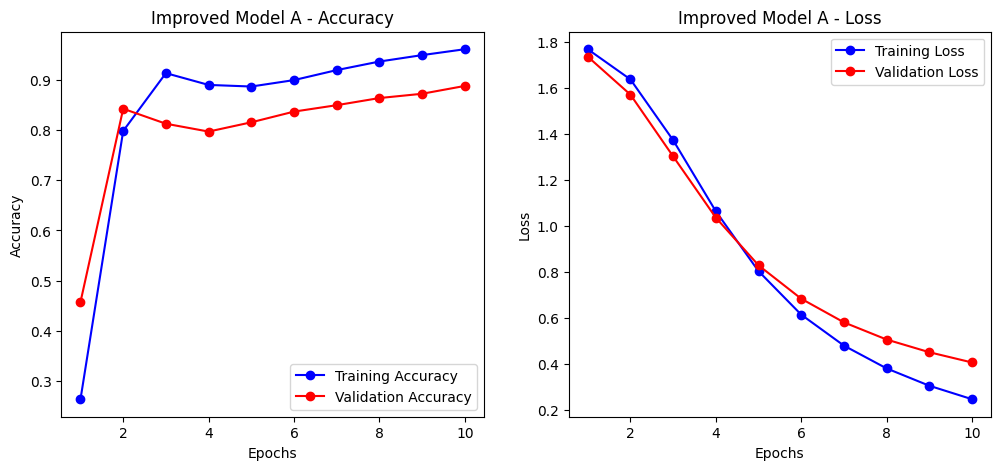

In [ ]:
# -------------------------
# Visualization: Plot Training and Validation Curves for Improved CNN
# -------------------------
epochs_range = range(1, len(history_cnn_tuned.history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_cnn_tuned.history['accuracy'], 'bo-', label='Training Accuracy')
plt.plot(epochs_range, history_cnn_tuned.history['val_accuracy'], 'ro-', label='Validation Accuracy')
plt.title('Improved Model A - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_cnn_tuned.history['loss'], 'bo-', label='Training Loss')
plt.plot(epochs_range, history_cnn_tuned.history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Improved Model A - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
print("\nSummary of Configurations:")
for res in results:
    print(f"{res['activation_func']}: Test Accuracy = {res['test_accuracy']:.4f}")


Summary of Configurations:
relu: Test Accuracy = 0.8792
sigmoid: Test Accuracy = 0.7989
tanh: Test Accuracy = 0.8681



Training with optimizer: adam
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1782 - loss: 1.7859 - val_accuracy: 0.3054 - val_loss: 1.7484
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6485 - loss: 1.7049 - val_accuracy: 0.7741 - val_loss: 1.6452
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9336 - loss: 1.5375 - val_accuracy: 0.8423 - val_loss: 1.3639
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9265 - loss: 1.1676 - val_accuracy: 0.8409 - val_loss: 1.0033
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9068 - loss: 0.8193 - val_accuracy: 0.8466 - val_loss: 0.7759
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9257 - loss: 0.5963 - val_accuracy: 0.8480 - val_loss: 0.6458
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9324 - loss: 0.4775 - val_accuracy: 0.8636 - val_loss: 0.5562
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9495 - loss: 0.

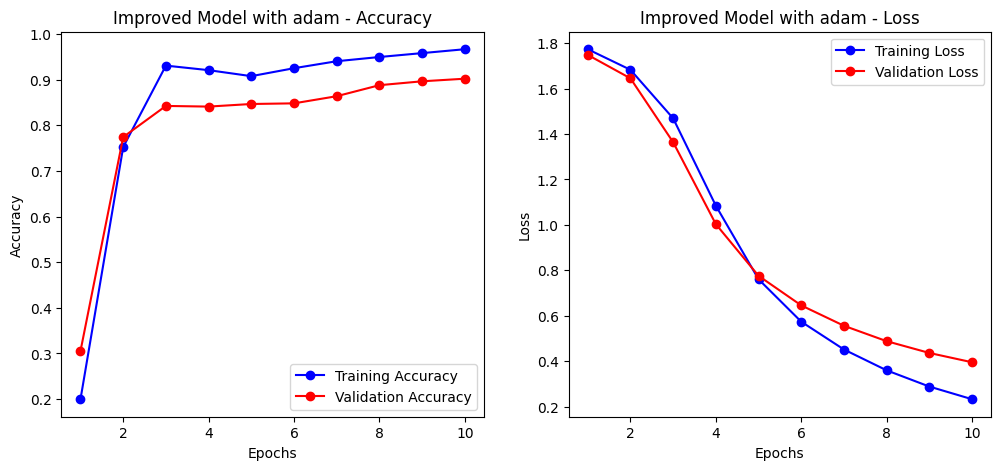


Training with optimizer: sgd
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1663 - loss: 1.7950 - val_accuracy: 0.1719 - val_loss: 1.7947
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1755 - loss: 1.7931 - val_accuracy: 0.1719 - val_loss: 1.7945
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1595 - loss: 1.7968 - val_accuracy: 0.1719 - val_loss: 1.7944
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1588 - loss: 1.7957 - val_accuracy: 0.1719 - val_loss: 1.7943
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1764 - loss: 1.7930 - val_accuracy: 0.1719 - val_loss: 1.7942
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1632 - loss: 1.7961 - val_accuracy: 0.1719 - val_loss: 1.7940
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1629 - loss: 1.7950 - val_accuracy: 0.1719 - val_loss: 1.7939
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1642 - loss: 1.7

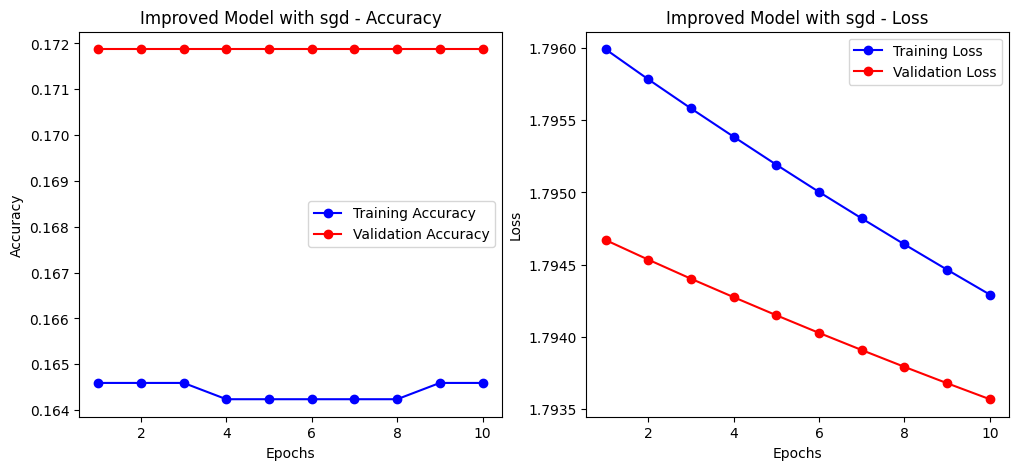


Training with optimizer: rmsprop
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2424 - loss: 1.7822 - val_accuracy: 0.5014 - val_loss: 1.7293
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6753 - loss: 1.6799 - val_accuracy: 0.6832 - val_loss: 1.5843
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8080 - loss: 1.4870 - val_accuracy: 0.7202 - val_loss: 1.3520
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8311 - loss: 1.2174 - val_accuracy: 0.7429 - val_loss: 1.1206
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8008 - loss: 0.9771 - val_accuracy: 0.7699 - val_loss: 0.9434
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8282 - loss: 0.8127 - val_accuracy: 0.7955 - val_loss: 0.8130
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8475 - loss: 0.6625 - val_accuracy: 0.8125 - val_loss: 0.7112
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8732 - loss:

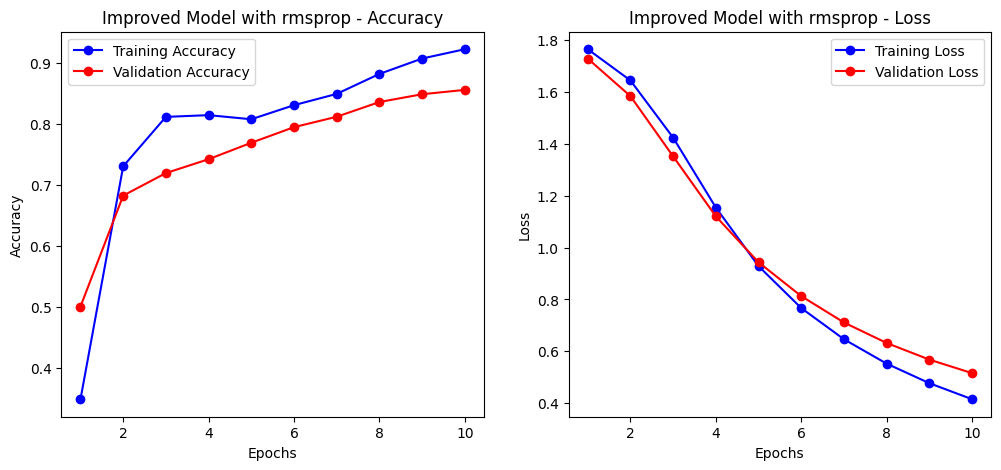


Summary of Optimizer Configurations:
adam: Test Accuracy = 0.8881
sgd: Test Accuracy = 0.1661
rmsprop: Test Accuracy = 0.8501


In [ ]:
# Hyperparameters (giữ nguyên các hyperparameter đã chọn)
embedding_dim = 64
max_len = 200
dropout_rate = 0.6
filters = 64
learning_rate = 0.0003
vocab_size = 15000  # Best vocab size from experiments
kernel_size = 3     # Best kernel size from experiments
activation_func = 'tanh' # best activation function from experiments # <---- ĐÃ SỬA

# Tokenization and Padding (giữ nguyên các bước đã làm)
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


# Define the optimizers to test
optimizers = ['adam', 'sgd', 'rmsprop']

# Dictionary to store results
results = []

for optimizer_name in optimizers:
    print(f"\nTraining with optimizer: {optimizer_name}")

    # Define the model (tương tự như model đã fine-tune, sử dụng activation function tốt nhất)
    model_cnn_tuned_opt = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        Conv1D(filters=filters, kernel_size=kernel_size, activation=activation_func),
        GlobalMaxPooling1D(),
        Dense(num_classes, activation='softmax') # Keep softmax for the output layer
    ])


    # Instantiate the optimizer
    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("Invalid optimizer choice.")

    # Compile the model
    model_cnn_tuned_opt.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    # Train the model, saving the history
    history_cnn_tuned_opt = model_cnn_tuned_opt.fit(
        X_train_pad, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    # Evaluate the model
    test_loss_cnn, test_acc_cnn = model_cnn_tuned_opt.evaluate(X_test_pad, y_test, verbose=0)
    print(f"Test Accuracy with {optimizer_name}: {test_acc_cnn:.4f}")


     # Save the configuration and results
    results.append({
        'optimizer': optimizer_name,
        'test_accuracy': test_acc_cnn,
        'history': history_cnn_tuned_opt.history
    })

    # -------------------------
    # Visualization: Plot Training and Validation Curves for Improved CNN
    # -------------------------
    epochs_range = range(1, len(history_cnn_tuned_opt.history['accuracy']) + 1)
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_cnn_tuned_opt.history['accuracy'], 'bo-', label='Training Accuracy')
    plt.plot(epochs_range, history_cnn_tuned_opt.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.title(f'Improved Model with {optimizer_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_cnn_tuned_opt.history['loss'], 'bo-', label='Training Loss')
    plt.plot(epochs_range, history_cnn_tuned_opt.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title(f'Improved Model with {optimizer_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Summary of all configurations
print("\nSummary of Optimizer Configurations:")
for res in results:
    print(f"{res['optimizer']}: Test Accuracy = {res['test_accuracy']:.4f}")


Training with loss function: categorical_crossentropy
Test Accuracy with categorical_crossentropy: 0.8783


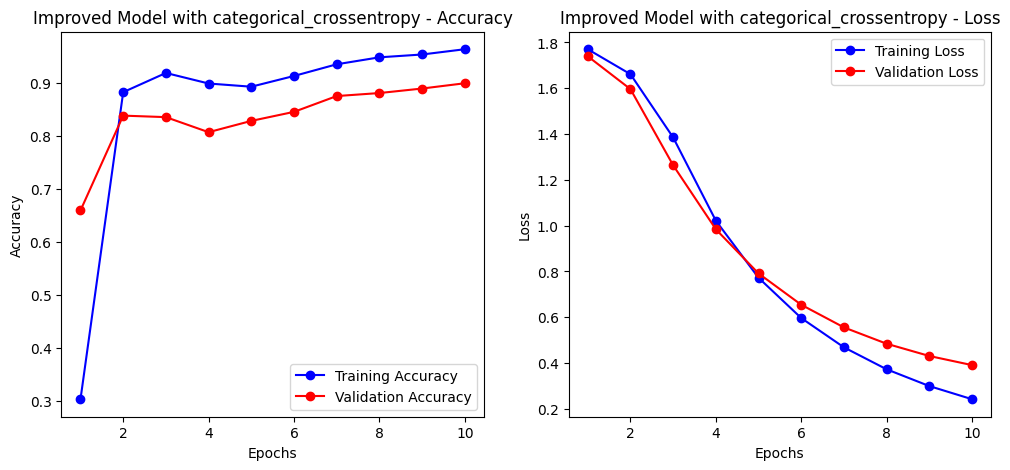


Training with loss function: sparse_categorical_crossentropy
Test Accuracy with sparse_categorical_crossentropy: 0.8664


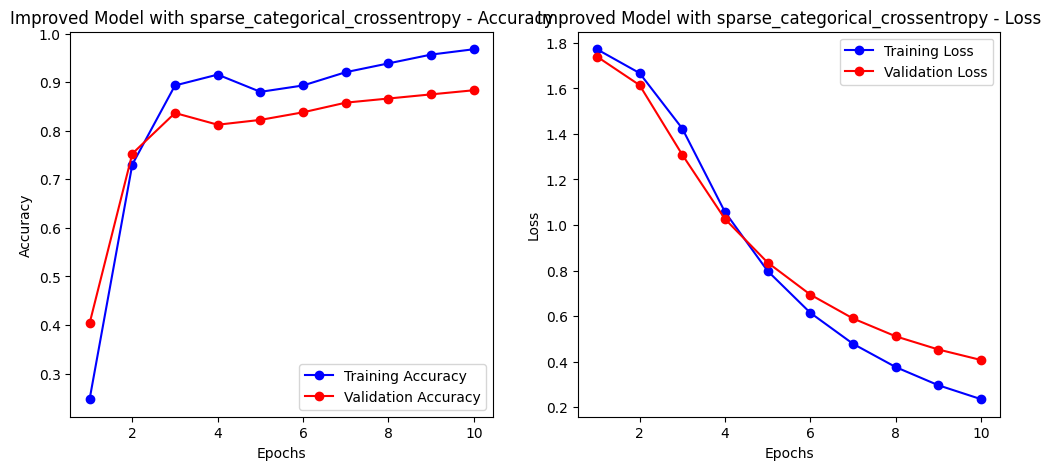


Summary of Loss Function Configurations:
categorical_crossentropy: Test Accuracy = 0.8783
sparse_categorical_crossentropy: Test Accuracy = 0.8664


In [ ]:
# Hyperparameters (giữ nguyên các hyperparameter đã chọn)
embedding_dim = 64
max_len = 200
dropout_rate = 0.6
filters = 64
learning_rate = 0.0003
vocab_size = 15000  # Best vocab size from experiments
kernel_size = 3     # Best kernel size from experiments
activation_func = 'tanh' # best activation function from experiments

# Tokenization and Padding (giữ nguyên các bước đã làm)
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Define the optimizers to test
optimizers = ['adam'] # best optimizer from previous step

# Define the loss functions to test
loss_functions = [
    'categorical_crossentropy',
    'sparse_categorical_crossentropy',
]

# Dictionary to store results
results = []

for loss_func_name in loss_functions:
    print(f"\nTraining with loss function: {loss_func_name}")

    # Define the model
    model_cnn_tuned_loss = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        Conv1D(filters=filters, kernel_size=kernel_size, activation=activation_func),
        GlobalMaxPooling1D(),
        Dense(num_classes, activation='softmax') # Keep softmax for the output layer
    ])
    # Instantiate the optimizer
    optimizer = Adam(learning_rate=learning_rate)

    # Compile the model
    if loss_func_name == 'categorical_crossentropy':
        model_cnn_tuned_loss.compile(
            loss=loss_func_name, # Use the current loss function
            optimizer=optimizer,
            metrics=['accuracy']
            )
        # Convert labels to one-hot encoded format
        y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
        y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=num_classes) # <---- ADDED
    else:
         model_cnn_tuned_loss.compile(
            loss=loss_func_name, # Use the current loss function
            optimizer=optimizer,
            metrics=['accuracy']
        )
         y_train_onehot = y_train # keep original labels
         y_test_onehot = y_test # keep original labels # <---- ADDED

    # Train the model, saving the history
    history_cnn_tuned_loss = model_cnn_tuned_loss.fit(
        X_train_pad, y_train_onehot, # Pass one-hot encoded labels when using categorical_crossentropy
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate the model
    test_loss_cnn, test_acc_cnn = model_cnn_tuned_loss.evaluate(X_test_pad, y_test_onehot, verbose=0) # <---- MODIFIED
    print(f"Test Accuracy with {loss_func_name}: {test_acc_cnn:.4f}")


     # Save the configuration and results
    results.append({
        'loss_function': loss_func_name,
        'test_accuracy': test_acc_cnn,
        'history': history_cnn_tuned_loss.history
    })

    # -------------------------
    # Visualization: Plot Training and Validation Curves for Improved CNN
    # -------------------------
    epochs_range = range(1, len(history_cnn_tuned_loss.history['accuracy']) + 1)
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_cnn_tuned_loss.history['accuracy'], 'bo-', label='Training Accuracy')
    plt.plot(epochs_range, history_cnn_tuned_loss.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.title(f'Improved Model with {loss_func_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_cnn_tuned_loss.history['loss'], 'bo-', label='Training Loss')
    plt.plot(epochs_range, history_cnn_tuned_loss.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title(f'Improved Model with {loss_func_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Summary of all configurations
print("\nSummary of Loss Function Configurations:")
for res in results:
    print(f"{res['loss_function']}: Test Accuracy = {res['test_accuracy']:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

# Download necessary NLTK resources if not already downloaded
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Load the dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Convert to a DataFrame for easier manipulation
df = pd.DataFrame({'text': newsgroups.data, 'target': newsgroups.target})

# Map target labels to their corresponding category names
df['category'] = df['target'].apply(lambda x: newsgroups.target_names[x])

# Initialize stemmer and lemmatizer
porter = PorterStemmer()  # Stemming: 'running' -> 'run'
wnl = WordNetLemmatizer()  # Lemmatization: 'better' -> 'good'

# Define preprocessing steps
def strip_tags(text):
    return re.sub(r'<[^>]+>', '', text)

def strip_numeric(text):
    return re.sub(r'\d+', '', text)

def strip_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

def to_lowercase(text):
    return text.lower()

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    return ' '.join([word for word in text.split() if word not in stop_words])

def lemmatize_text(text):
    return ' '.join([wnl.lemmatize(word) for word in text.split()])

def preprocess_text(text):
    text = strip_tags(text)
    text = strip_numeric(text)
    text = strip_punctuation(text)
    text = to_lowercase(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

# Filter the dataframe to include only the specified categories
categories = ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'misc.forsale', 'talk.politics.mideast', 'rec.autos']
filtered_df = df[df['category'].isin(categories)].copy()

# Fetch the 20 Newsgroups dataset
data_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42
)

data_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42
)

# Extract text data and labels
X_train_text = data_train.data  # Training text data
X_test_text = data_test.data    # Test text data
y_train = data_train.target     # Training labels
y_test = data_test.target       # Test labels

# Convert labels to consecutive integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

num_classes = len(np.unique(y_train))

# Apply preprocessing to the training and test sets
X_train_cleaned = [preprocess_text(text) for text in X_train_text]
X_test_cleaned = [preprocess_text(text) for text in X_test_text]

# Hyperparameter grids
vocab_sizes = [10000, 15000, 20000]
kernel_sizes = [3, 5, 7]
batch_sizes = [32, 64, 128]
learning_rates = [0.0001, 0.0003, 0.001]

# To store results for later comparison
results = []

# Loop over all combinations
for vocab_size in vocab_sizes:
    for kernel_size in kernel_sizes:
        for batch_size in batch_sizes:
            for learning_rate in learning_rates:
                config = f"vocab={vocab_size}, kernel={kernel_size}, batch={batch_size}, lr={learning_rate}"
                print(f"\nTraining with {config}")

                # --- Tokenization and Padding ---
                tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
                tokenizer.fit_on_texts(X_train_cleaned)
                X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
                X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)
                max_len = 200
                X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
                X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

                # Simplified Model
                model_cnn = Sequential([
                    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
                    Conv1D(filters=64, kernel_size=kernel_size, activation='tanh'),
                    GlobalMaxPooling1D(),
                    Dense(num_classes, activation='softmax')
                ])

                # --- Compile the Model ---
                optimizer = Adam(learning_rate=learning_rate)

                model_cnn.compile(
                    loss='sparse_categorical_crossentropy',
                    optimizer=optimizer,
                    metrics=['accuracy']
                )

                # --- Train the Model ---
                history_cnn = model_cnn.fit(
                    X_train_pad, y_train,
                    epochs=10,
                    batch_size=batch_size,
                    validation_split=0.2,
                    verbose=0  # Set verbose to 0 to reduce output during training
                )

                # --- Evaluate the Model ---
                test_loss, test_accuracy = model_cnn.evaluate(X_test_pad, y_test, verbose=0)
                print(f"Test Accuracy with {config}: {test_accuracy:.4f}")


                # Save the configuration and results
                results.append({
                    'config': config,
                    'vocab_size': vocab_size,
                    'kernel_size': kernel_size,
                    'batch_size': batch_size,
                    'learning_rate': learning_rate,
                    'test_accuracy': test_accuracy,
                    'history': history_cnn.history
                })

# --- Summary of All Configurations ---
print("\nSummary of Configurations:")
for res in results:
    print(f"{res['config']}: Test Accuracy = {res['test_accuracy']:.4f}")


Training with vocab=10000, kernel=3, batch=32, lr=0.0001


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Test Accuracy with vocab=10000, kernel=3, batch=32, lr=0.0001: 0.8079

Training with vocab=10000, kernel=3, batch=32, lr=0.0003
Test Accuracy with vocab=10000, kernel=3, batch=32, lr=0.0003: 0.8800

Training with vocab=10000, kernel=3, batch=32, lr=0.001
Test Accuracy with vocab=10000, kernel=3, batch=32, lr=0.001: 0.9214

Training with vocab=10000, kernel=3, batch=64, lr=0.0001
Test Accuracy with vocab=10000, kernel=3, batch=64, lr=0.0001: 0.7997

Training with vocab=10000, kernel=3, batch=64, lr=0.0003
Test Accuracy with vocab=10000, kernel=3, batch=64, lr=0.0003: 0.8540

Training with vocab=10000, kernel=3, batch=64, lr=0.001
Test Accuracy with vocab=10000, kernel=3, batch=64, lr=0.001: 0.9108

Training with vocab=10000, kernel=3, batch=128, lr=0.0001
Test Accuracy with vocab=10000, kernel=3, batch=128, lr=0.0001: 0.7178

Training with vocab=10000, kernel=3, batch=128, lr=0.0003
Test Accuracy with vocab=10000, kernel=3, batch=128, lr=0.0003: 0.8151

Training with vocab=10000, kernel

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3655 - loss: 1.7492 - val_accuracy: 0.6932 - val_loss: 1.3870 - learning_rate: 0.0010
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8669 - loss: 1.0537 - val_accuracy: 0.8636 - val_loss: 0.6502 - learning_rate: 0.0010
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9324 - loss: 0.4152 - val_accuracy: 0.9048 - val_loss: 0.3883 - learning_rate: 0.0010
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9689 - loss: 0.2003 - val_accuracy: 0.9205 - val_loss: 0.2865 - learning_rate: 0.0010
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9871 - loss: 0.0878 - val_accuracy: 0.9261 - val_loss: 0.2403 - learning_rate: 0.0010
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9977 - loss: 0.0426 - val_accuracy: 0.9276 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9992 - loss: 0.0244 - val_accuracy: 0.93

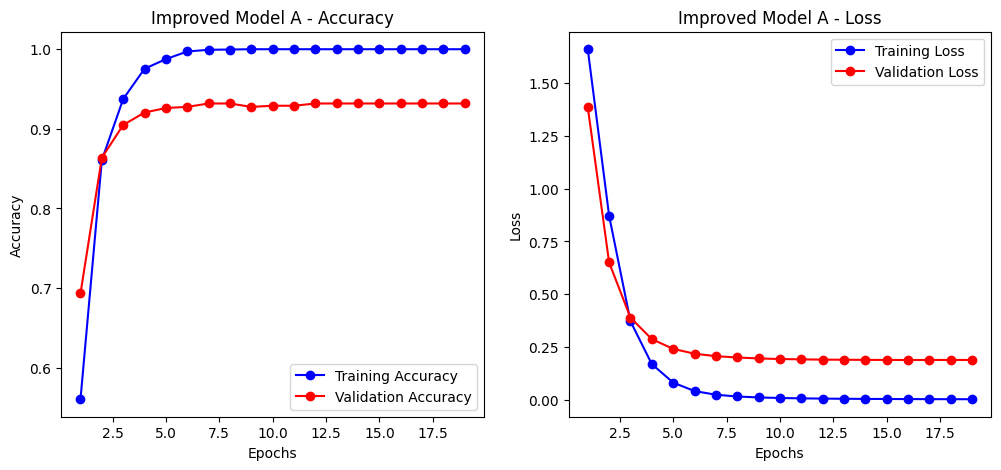

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

# Download necessary NLTK resources if not already downloaded
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Load the dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Convert to a DataFrame for easier manipulation
df = pd.DataFrame({'text': newsgroups.data, 'target': newsgroups.target})

# Map target labels to their corresponding category names
df['category'] = df['target'].apply(lambda x: newsgroups.target_names[x])

# Initialize stemmer and lemmatizer
porter = PorterStemmer()  # Stemming: 'running' -> 'run'
wnl = WordNetLemmatizer()  # Lemmatization: 'better' -> 'good'

# Define preprocessing steps
def strip_tags(text):
    return re.sub(r'<[^>]+>', '', text)

def strip_numeric(text):
    return re.sub(r'\d+', '', text)

def strip_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

def to_lowercase(text):
    return text.lower()

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    return ' '.join([word for word in text.split() if word not in stop_words])

def lemmatize_text(text):
    return ' '.join([wnl.lemmatize(word) for word in text.split()])

def preprocess_text(text):
    text = strip_tags(text)
    text = strip_numeric(text)
    text = strip_punctuation(text)
    text = to_lowercase(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

# Filter the dataframe to include only the specified categories
categories = ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'misc.forsale', 'talk.politics.mideast', 'rec.autos']
filtered_df = df[df['category'].isin(categories)].copy()

# Fetch the 20 Newsgroups dataset
data_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42
)

data_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42
)

# Extract text data and labels
X_train_text = data_train.data  # Training text data
X_test_text = data_test.data    # Test text data
y_train = data_train.target     # Training labels
y_test = data_test.target       # Test labels

# Convert labels to consecutive integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

num_classes = len(np.unique(y_train))

# Apply preprocessing to the training and test sets
X_train_cleaned = [preprocess_text(text) for text in X_train_text]
X_test_cleaned = [preprocess_text(text) for text in X_test_text]

# Hyperparameters
embedding_dim = 64
max_len = 200
dropout_rate = 0.6
filters = 64
learning_rate = 0.001
vocab_size = 20000  # Best vocab size from experiments
kernel_size = 5     # Best kernel size from experiments
activation_func = 'tanh' # best activation function from experiments

# Tokenization and Padding
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Define the model
model_cnn_tuned = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Conv1D(filters=filters, kernel_size=kernel_size, activation=activation_func),
    GlobalMaxPooling1D(),
    Dense(num_classes, activation='softmax')
])

# Instantiate the optimizer
optimizer = Adam(learning_rate=learning_rate)

# Compile the model
model_cnn_tuned.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001,
    verbose=1
)


# Train the model with callbacks
history_cnn_tuned = model_cnn_tuned.fit(
    X_train_pad, y_train,
    epochs=20,  # Increased epochs, but training will stop early
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


# Evaluate the model
test_loss_cnn, test_acc_cnn = model_cnn_tuned.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {test_acc_cnn:.4f}")

# Predictions
y_pred_cnn = model_cnn_tuned.predict(X_test_pad)

# Convert predictions to class labels
y_pred_cnn = y_pred_cnn.argmax(axis=1)

# Classification reports
print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=categories))

# -------------------------
# Visualization: Plot Training and Validation Curves for Improved CNN
# -------------------------
epochs_range = range(1, len(history_cnn_tuned.history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_cnn_tuned.history['accuracy'], 'bo-', label='Training Accuracy')
plt.plot(epochs_range, history_cnn_tuned.history['val_accuracy'], 'ro-', label='Validation Accuracy')
plt.title('Improved Model A - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_cnn_tuned.history['loss'], 'bo-', label='Training Loss')
plt.plot(epochs_range, history_cnn_tuned.history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Improved Model A - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Print the full history for FCNN
print("=== CNN Training History (Epoch by Epoch) ===")
for i in range(len(history_cnn_tuned.history['accuracy'])):
    epoch_num = i + 1
    train_loss = history_cnn_tuned.history['loss'][i]
    train_acc = history_cnn_tuned.history['accuracy'][i]
    val_loss = history_cnn_tuned.history['val_loss'][i]
    val_acc = history_cnn_tuned.history['val_accuracy'][i]

    print(f"Epoch {epoch_num:2d} | "
          f"Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Val Acc: {val_acc:.4f}")


=== CNN Training History (Epoch by Epoch) ===
Epoch  1 | Train Loss: 1.6620, Train Acc: 0.5603, Val Loss: 1.3870, Val Acc: 0.6932
Epoch  2 | Train Loss: 0.8720, Train Acc: 0.8606, Val Loss: 0.6502, Val Acc: 0.8636
Epoch  3 | Train Loss: 0.3712, Train Acc: 0.9374, Val Loss: 0.3883, Val Acc: 0.9048
Epoch  4 | Train Loss: 0.1680, Train Acc: 0.9755, Val Loss: 0.2865, Val Acc: 0.9205
Epoch  5 | Train Loss: 0.0803, Train Acc: 0.9876, Val Loss: 0.2403, Val Acc: 0.9261
Epoch  6 | Train Loss: 0.0401, Train Acc: 0.9972, Val Loss: 0.2173, Val Acc: 0.9276
Epoch  7 | Train Loss: 0.0227, Train Acc: 0.9993, Val Loss: 0.2057, Val Acc: 0.9318
Epoch  8 | Train Loss: 0.0143, Train Acc: 0.9996, Val Loss: 0.1994, Val Acc: 0.9318
Epoch  9 | Train Loss: 0.0099, Train Acc: 1.0000, Val Loss: 0.1948, Val Acc: 0.9276
Epoch 10 | Train Loss: 0.0072, Train Acc: 1.0000, Val Loss: 0.1922, Val Acc: 0.9290
Epoch 11 | Train Loss: 0.0055, Train Acc: 1.0000, Val Loss: 0.1905, Val Acc: 0.9290
Epoch 12 | Train Loss: 0.0043,

In [ ]:
# Evaluate on the test set
test_loss_cnn, test_acc_cnn = model_cnn_tuned.evaluate(X_test_pad, y_test, verbose=0)
print(f"Fine-tuned CNN Test Accuracy: {test_acc_cnn:.4f}")

Fine-tuned CNN Test Accuracy: 0.9116


In [ ]:
# Predictions
y_pred_cnn = model_cnn_tuned.predict(X_test_pad)

# Convert predictions to class labels
y_pred_cnn = y_pred_cnn.argmax(axis=1)

# Classification reports
print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=categories))

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
CNN Classification Report:
                       precision    recall  f1-score   support

        comp.graphics       0.87      0.87      0.87       389
   rec.sport.baseball       0.85      0.90      0.88       390
            sci.space       0.93      0.88      0.90       396
         misc.forsale       0.94      0.97      0.96       397
talk.politics.mideast       0.91      0.92      0.91       394
            rec.autos       0.98      0.93      0.95       376

             accuracy                           0.91      2342
            macro avg       0.91      0.91      0.91      2342
         weighted avg       0.91      0.91      0.91      2342



In [ ]:
np.savetxt("y_pred_cnn.csv", y_pred_cnn, delimiter=",", fmt='%d')